# Time Series Analysis: Anomaly Detection

Time series often record real-world processes - these processes usually produce **regular** patterns. However, **anomalies** can occur and their detection can be interesting or even critical for the system measured. An example would be air quality measurements, where an anomalous high spike can be dangerous to our health.

Anomaly detection heavily relies on defining what a normal signal looks like. There are several approaches, e.g. comparing to other parts of the time series or against a model. The survey specifically notes that Deep Learning model are not yet competitive, especially regarding their higher resource demand.

This notebook implements some anomaly detection algorithms from the survey presented in the lecture:
- **Matrix Profile**: Foundational time series analysis **distance** tool - Splitting the data into blocks and comparing their similarity
- **ARIMA**: Foundational **statistical forecasting** model - Combining three models to accurately describe a time series
- **DWT-MLEAD**: Allrounder with good runtime and accuracy based on **wavelets**
- **Isolation Forest**: A **Machine Learning** model isolating anomalous points from regular ones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import meteostat as ms
from datetime import datetime

Lets import some weather data around Bolzano:

In [2]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=1, radius=1000000)
station_ids = stations.index.tolist()

start = datetime(2023, 7, 1)
end = datetime(2023, 9, 30)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

ts_data = data.fetch().reset_index().pivot(index='time', columns='station', values='temp')

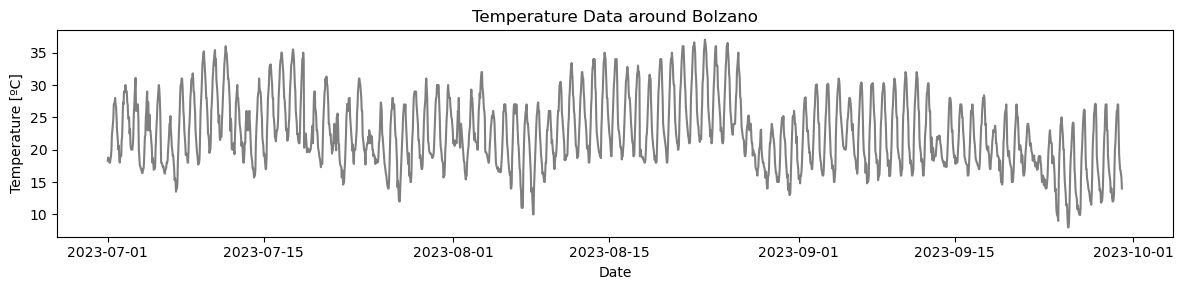

In [3]:
plt.figure(figsize=(12, 3))
plt.title("Temperature Data around Bolzano")
plt.plot(ts_data, color='black', alpha=0.5)

plt.xlabel("Date")
plt.ylabel("Temperature [ºC]")
plt.tight_layout()
plt.show()

Lets add several **anomalies** that have also been used in the survey:
1. An **extremum** anomaly: A point anomaly that adds a massive spike to the data

2. A **variation** anomaly: A consecutive anomaly adding more variation for a short period
3. A **frequency** anomaly: A consecutive anomaly changing the frequency for a short period
4. A **shift** anomaly: A contextual anomaly allowing a slight phase shift in the data
5. A **pattern** anomaly: A contextual anomaly reversing the data of a short period

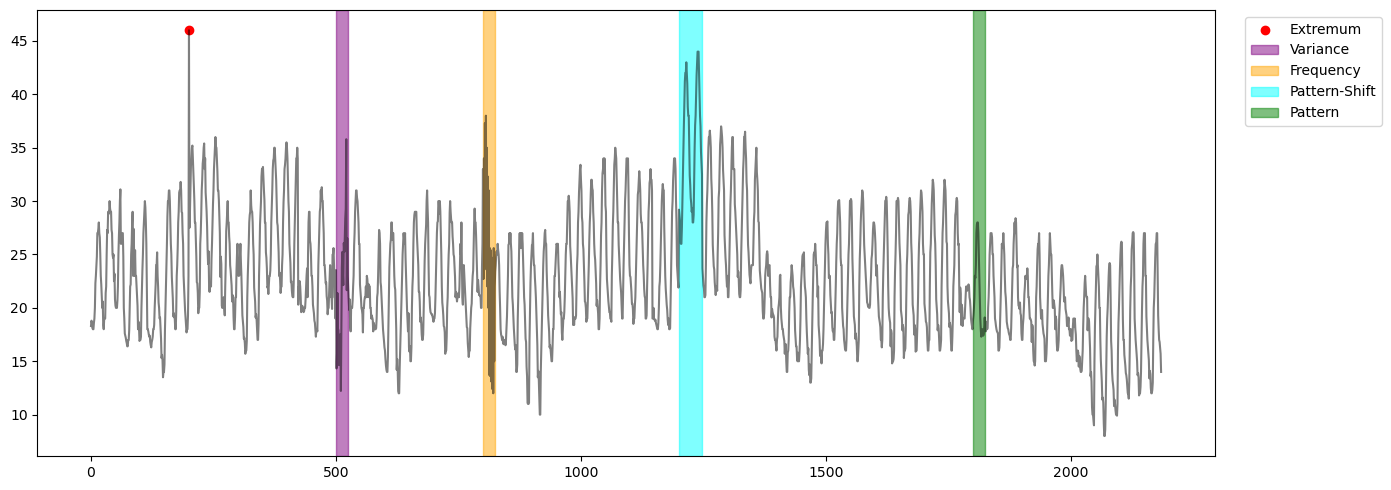

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Anomaly Indices
idx_ext = 200                             
idx_var_start, idx_var_end = 500, 524          
idx_freq_start, idx_freq_end = 800, 824        
idx_shift_start, idx_shift_end = 1200, 1248 
idx_pat_start, idx_pat_end = 1800, 1824

true_anomalies = [idx_ext, idx_var_start, idx_freq_start, idx_shift_start, idx_pat_start]

# Setup Data
clean_ts = ts_data[ts_data.columns[0]].to_numpy()
ts_data_anomalous = np.copy(clean_ts)
x = np.arange(len(ts_data_anomalous))

# Inject Anomalies
ts_data_anomalous[idx_ext] += 20.0  # Extremum
ts_data_anomalous[idx_var_start:idx_var_end] += np.random.normal(0, 4.0, idx_var_end - idx_var_start)  # Variance
ts_data_anomalous[idx_freq_start:idx_freq_end] += np.tile([6.0, -6.0], (idx_freq_end - idx_freq_start) // 2)  # Frequency
ts_data_anomalous[idx_shift_start:idx_shift_end] += 8.0  # Pattern-Shift
ts_data_anomalous[idx_pat_start:idx_pat_end] = clean_ts[idx_pat_start:idx_pat_end][::-1]  # Pattern

# Plot
plt.figure(figsize=(14, 5))
plt.plot(x, ts_data_anomalous, color='black', alpha=0.5)
plt.scatter(idx_ext, ts_data_anomalous[idx_ext], color='red', label='Extremum')
plt.axvspan(idx_var_start, idx_var_end, color='purple', label='Variance', alpha=0.5)
plt.axvspan(idx_freq_start, idx_freq_end, color='orange', label='Frequency', alpha=0.5)
plt.axvspan(idx_shift_start, idx_shift_end, color='cyan', label='Pattern-Shift', alpha=0.5)
plt.axvspan(idx_pat_start, idx_pat_end, color='green', label='Pattern', alpha=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1. Matrix Profile

The Matrix Profile is based on splitting the time series in overlapping **windows**, e.g. blocks of 30 data points starting at 0, 1, ... . Then, the **pairwise distance** of the blocks can be calculated.

From those pairwise distances, one can extract the smallest distance for each window - the most similar block. Usually, an **exclusion zone** around the current window is applied to exclude the overlapping windows. This is necessary as they could always be the most similar window as they share most data points. In the end, this yields for each window one distance and index of the respective most similar window. 

All distances give the **Matrix Profile** and all respective indices the **Matrix Profile Index**. This profile can be utilized for a number of time series analysis tasks, e.g. clustering, change point detection or anomaly detection. 

For anomaly detection, one can search for the maximum value within the profile. This **discord** value represents the window that is the most dissimilar to all others and thus most likely contains an anomaly. 

### 1.1. Naive Implementation

A naive implementation of the distance matrix from which the matrix profile can be extracted just calculates the pairwise distances between the windows. The extraction only requires the distances of the current window, so not all pairwise distances have to be stored at once.

However, a pairwise calculation takes $\mathcal{O}(n^2m)$ for a time series length $n$ and window size $m$. Next to the obviously bad runtime, having the complexity depend on the window size is also unwanted. Time series can have entirely different appropriate window sizes which would drastically influence the runtime.

In [5]:
from scipy.stats import zscore

def matrix_profile_naive(time_series, window_size):
    # 1: Initilization
    n = len(time_series)
    n_windows = n - window_size + 1
    exclusion_zone = window_size // 4

    matrix_profile = np.full(n_windows, np.inf)
    matrix_profile_index = np.zeros(n_windows, dtype=int)
    
    windows = np.array([zscore(time_series[i:i+window_size]) for i in range(n_windows)]) # Precompute to remove redundancy

    # 2: Loop through Distance Matrix
    for i in range(n_windows):
        for j in range(n_windows):
            # 2.1: Skip exclusion zone
            if abs(i - j) <= exclusion_zone:
                continue
            
            # 2.2: Calculate pairwise distance
            dist = np.linalg.norm(windows[i] - windows[j])

            # 2.3: Update Matrix Profile and Index for window
            if dist < matrix_profile[i]:
                matrix_profile[i] = dist
                matrix_profile_index[i] = j
    
    return matrix_profile, matrix_profile_index

### 1.2. STOMP Implementation

As a consequence, a faster way for the distance calculation over the whole time series was invented which utilizes the **overlapping property** of the windows - the algorithm was called **STOMP**. It implements a neat mathematical trick that allows a **rolling update** of the distances (see below).

As we still need pairwise distances, the complexity remains $\mathcal{O}(n^2)$, but dropping the window size factor $m$! As with the naive implementation, the matrix profile can be computed column-wise without building the whole distance matrix. This allows a high degree of **parallelization**, which we omit for clarity. 

It features an extensive amount of literature build on top of the initial matrix profile idea. An overview can be found [here](https://www.cs.ucr.edu/~eamonn/MatrixProfile.html).

-----

In order to function efficiently, it **precomputes** the mean and standard deviation for each window. This enables a fast lookup as they are extensively used in STOMP. A trick of **cumulative sums** is used to compute the mean and std for each window within a few lines of code.

To compute the sliding dot product of a window sliding across the time series, another mathematical trick is used for speed up: By transforming the window to the **frequency domain** via DFT, the complex sliding and dot product procedure gets reduced to multiplying the respective frequencies (Convolution Theorem, see an introductory video [here](https://www.youtube.com/watch?v=KuXjwB4LzSA)). Transforming it back to the time domain gives the dot products.

To calculate the distance between the windows from the rolling dot product, the equivalence between Euclidean Distance and Pearson Correlation is used:
$$ED(X, Y) = \sqrt{2w \cdot (1 - PC)} = \sqrt{2w \cdot (1 - \frac{X \cdot Y - w \mu_x \mu_y}{w \sigma_x \sigma_y})}$$

If a window is perfectly flat its standard deviation is 0, which would cause a division by zero in this formula. In practice, we add a tiny noise factor (like 1e-10) to the denominator to safely handle flat subsequences.

As means and standard deviations are precomputed and the dot product efficiently updated (see below), the distance calculation just has to pass the values to the formula.

The matrix profile can be efficiently updated given a new distance profile: Wherever the distance profile is lower than the matrix profile, we have found a better window match. Only those position in the matrix profile and index are updated.

In [6]:
from scipy.fft import fft, ifft

def compute_mean_std(time_series, window_size):
    # Pad time series for correct cumsum result
    X_padded = np.insert(time_series, 0, 0)

    # Calculate (squared) cumulative sums of the time series 
    sum_X = np.cumsum(X_padded)
    sum_X_sq = np.cumsum(X_padded ** 2)

    # The mean is the difference of the first and last values of the window divided by the window size
    rolling_sum_X = sum_X[window_size:] - sum_X[:-window_size]
    mean = rolling_sum_X / window_size

    # The standard deviation can be derived in a similar manner to the mean
    rolling_sum_X_sq = sum_X_sq[window_size:] - sum_X_sq[:-window_size]
    std_sq = (rolling_sum_X_sq / window_size) - mean**2
    std = np.sqrt(std_sq)

    return mean, std

def sliding_dot_product(query, time_series):
    n = len(time_series)
    m = len(query)

    # Pad series correct convolution calculation
    padded_time_series = np.append(time_series, np.zeros(n))
    reversed_query = np.flip(query)
    padded_reversed_query = np.append(reversed_query, np.zeros(2*n - m))

    # Transform sequences to frequency domain
    fft_query = fft(padded_reversed_query)
    fft_time_series = fft(padded_time_series)

    # Efficiently calculate dot product and transform back to time domain
    dot_products = ifft(np.multiply(fft_query, fft_time_series)).real
    return dot_products[m-1:n] # Exclude query window

def calculate_distance_profile(dot_products, means, stds, idx, window_size):
    # Fetch mean and std of current window
    query_mean = means[idx]
    query_std = stds[idx]

    # Calculate correlation of windows
    centered_dot_product = dot_products - (window_size * means * query_mean)
    norm_factor = (window_size * stds * query_std)
    
    pearson_correlation = centered_dot_product / (norm_factor + 1e-10) # safe guard 0-division for flat subsequences

    # Pearson Correlation to Euclidean Distance translation
    distances = np.sqrt(2 * window_size * (1 - np.clip(pearson_correlation, -1.0, 1.0))) # safe guard floating point error in correlation
                        
    return distances

def element_wise_min(profile, profile_index, candidate, idx):
    # Find new best distances
    update_min_mask = candidate < profile

    # Update profile and index
    profile[update_min_mask] = candidate[update_min_mask]
    profile_index[update_min_mask] = idx

    return profile, profile_index

The STOMP algorithm first calculates the mean and standard deviation for each window.

It then starts the computation by processing the first window. The dot products to all other windows are calculated and the matrix profile is set equal to the distances obtained by the first window.

Iterating through the windows, the dot product can be updated rollingly. It uses the past dot product, the two values that are moved into the window and the windows themselves. The distance vector for that window can then be calculated from the dot product.

Finally, after applying the exclusion zone, the matrix profile can be updated with the new distance values.


In [ ]:
def matrix_profile_stomp(time_series, window_size):
    # 1: Initialize profile wide variables
    n = len(time_series)
    n_windows = n - window_size + 1
    exclusion_zone = int(np.ceil(window_size / 4))

    mean, std = compute_mean_std(time_series, window_size)

    # 2: Start computation with first window
    dot = sliding_dot_product(time_series[:window_size], time_series)
    dot_first = dot.copy()

    dist = calculate_distance_profile(dot_first, mean, std, 0, window_size)
    dist[0:min(n_windows, exclusion_zone + 1)] = np.inf

    # Intialize Matrix Profile
    matrix_profile = dist.copy()
    matrix_profile_index = np.ones(n_windows)

    # 3: Loop through windows
    for i in range(1, n_windows):
        # 3.1: Apply speedup trick
        for j in range(n_windows-1, 0, -1):
            dot[j] = (dot[j-1] 
                      - time_series[j-1] * time_series[i-1]
                      + time_series[j+window_size-1] * time_series[i+window_size-1]
            )
        dot[0] = dot_first[i]
        
        # 3.2: Calculate distance vector for window given the rolling dot product
        dist = calculate_distance_profile(dot, mean, std, i, window_size)

        # 3.3: Apply exclusion zone
        exclusion_start = max(0, i - exclusion_zone)
        exclusion_end = min(n_windows, i + exclusion_zone + 1)
        dist[exclusion_start : exclusion_end] = np.inf
        
        # 3.4: Update Matrix Profile
        matrix_profile, matrix_profile_index = element_wise_min(
            matrix_profile, matrix_profile_index, dist, i
        )
        
    return matrix_profile, matrix_profile_index

### 1.3. Experiments
The following plot shows a time series and its matrix profile. Furthermore, it shows the most similar subsequences (motifs) and the most dissimilar subsequence (discord/anomaly). Notice the following features:
- The windows are compared **z-normalized**, which might yield unexpected results in the unnormalized data
- The matrix profile is exactly $m-1$ data points **shorter** than the time series, as any point within the last window cannot be evaluated
- The **motif pair** always has the same distances. In general, the matrix profile is not symmetrical
- The **discord** still has a nearest window

How to read the matrix profile: <br> The window starting at $a$ has a distance $d$ (not locational, but ED!) to its most similar window $b$ shown in the matrix profile at $a$. The starting point $b$ of this most similar window can be found at the matrix profile index at $a$.

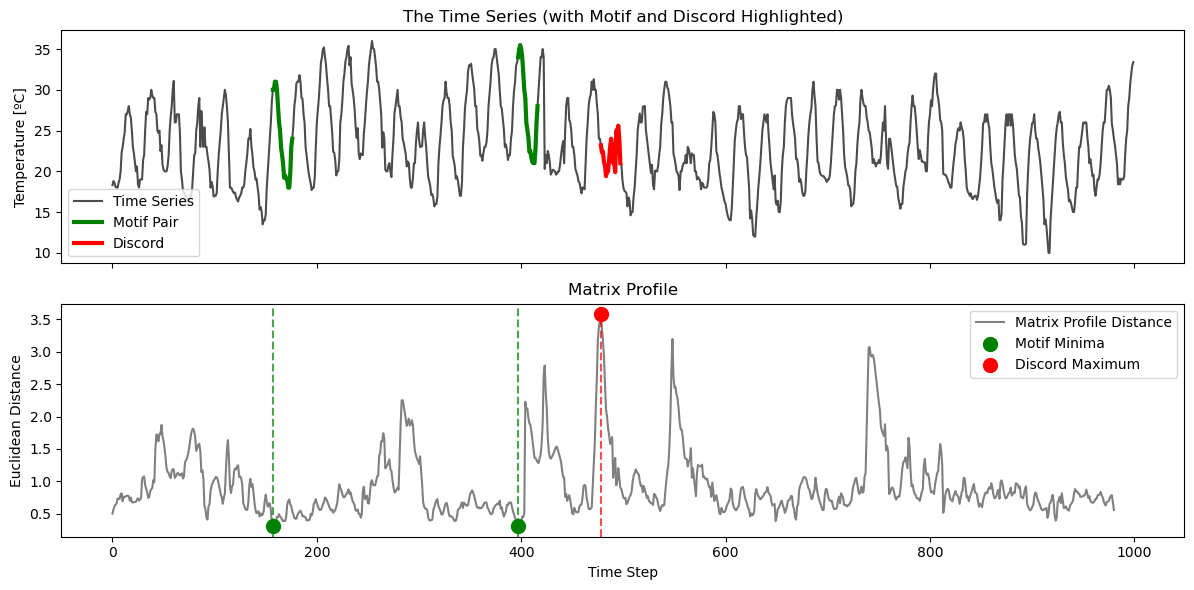

In [ ]:
# Compute the Matrix Profile and the Matrix Profile Index
ts = ts_data["16020"].to_numpy()[:1000]
window_size = 20

# Matrix Profile and important features
mp, mpi = matrix_profile_stomp(ts, window_size)
motif_idx_1 = np.argmin(mp)
motif_idx_2 = int(mpi[motif_idx_1])
discord_idx = np.argmax(mp)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.set_title("The Time Series (with Motif and Discord Highlighted)")
ax1.plot(ts, color='black', alpha=0.7, label="Time Series")
ax1.plot(range(motif_idx_1, motif_idx_1 + window_size), ts[motif_idx_1 : motif_idx_1 + window_size], color='green', linewidth=3, label="Motif Pair")
ax1.plot(range(motif_idx_2, motif_idx_2 + window_size), ts[motif_idx_2 : motif_idx_2 + window_size], color='green', linewidth=3)
ax1.plot(range(discord_idx, discord_idx + window_size), ts[discord_idx : discord_idx + window_size], color='red', linewidth=3, label="Discord")
ax1.set_ylabel("Temperature [ºC]")
ax1.legend()

ax2.set_title("Matrix Profile")
ax2.plot(np.pad(mp, (0, window_size), constant_values=np.nan), color='gray', label="Matrix Profile Distance")
ax2.axvline(x=motif_idx_1, color='green', linestyle='--', alpha=0.7)
ax2.axvline(x=motif_idx_2, color='green', linestyle='--', alpha=0.7)
ax2.scatter([motif_idx_1, motif_idx_2], [mp[motif_idx_1], mp[motif_idx_2]], color='green', s=100, zorder=5, label="Motif Minima")
ax2.axvline(x=discord_idx, color='red', linestyle='--', alpha=0.7)
ax2.scatter([discord_idx], [mp[discord_idx]], color='red', s=100, zorder=5, label="Discord Maximum")
ax2.set_ylabel("Euclidean Distance")
ax2.set_xlabel("Time Step")
ax2.legend()

plt.tight_layout()
plt.show()

Lets evaluate the runtime of the naive and stomp implementation: 

Even on only some hundred data points, the STOMP performs severely better than the naive implementation. The resulting matrix profiles are identical.

In [9]:
%%time
mp_naiv, mpi_naive = matrix_profile_naive(ts, window_size)

CPU times: user 2.55 s, sys: 0 ns, total: 2.55 s
Wall time: 2.55 s


In [10]:
%%time
mp_stomp, mpi_stomp = matrix_profile_stomp(ts, window_size)

CPU times: user 627 ms, sys: 1.18 ms, total: 628 ms
Wall time: 624 ms


In [11]:
print(f"Naive and STOMP are equal: {np.allclose(mp_naiv, mp_stomp)}")

Naive and STOMP are equal: True


### 1.4. Anomaly Detection

And finally, lets try to detect some anomalies with our STOMP implementation.

We are implementing a very simple algorithm that finds the top $k$ discords in the algorithm. It is applying a buffer zone around each found discord so that contextual anomalies are not flagged multiple times.

There are more refined anomaly detection algorithms build on top the matrix profile, e.g. MERLIN which calculates the matrix profile for every possible window size and selects the most meaningfull discords.

In [12]:
window_size = 50
matrix_profile, matrix_profile_index = matrix_profile_stomp(ts_data_anomalous, window_size=window_size)

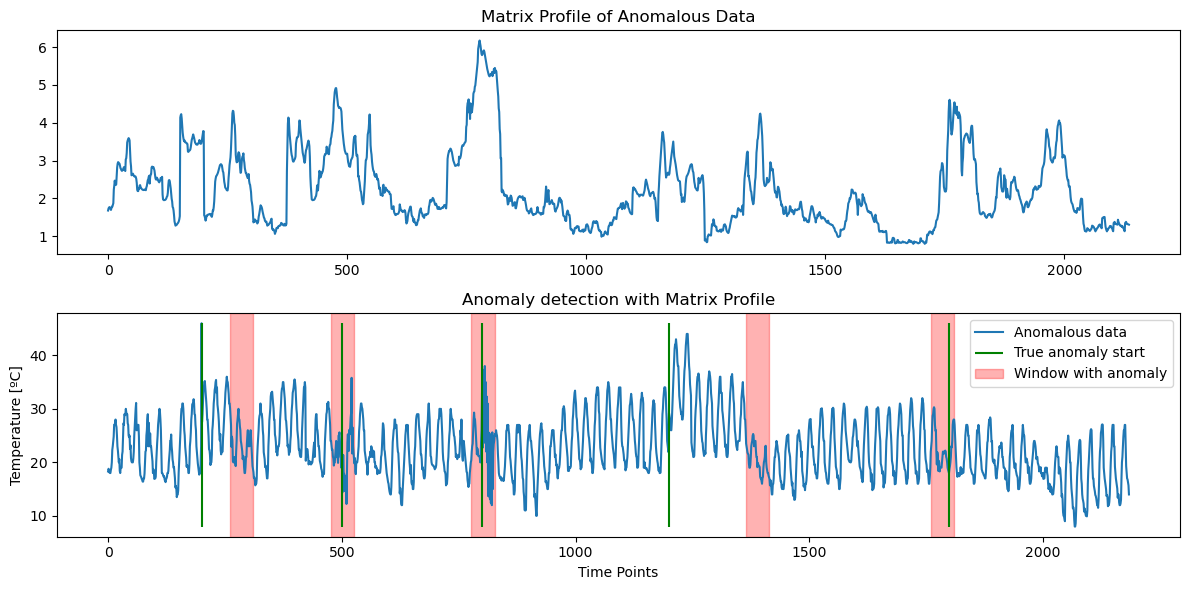

In [13]:
n_anomalies = 5

def find_top_k_discords(mp, k, window_size):
    mp_copy = np.copy(mp)
    discords = []

    for _ in range(k):
        idx = np.argmax(mp_copy)
        discords.append(idx)
        
        # Apply the exclusion zone to flatten the hump
        start = max(0, idx - window_size)
        end = min(len(mp_copy), idx + window_size + 1)
        mp_copy[start:end] = -np.inf

    return discords

mp_anomalies = find_top_k_discords(matrix_profile, n_anomalies, window_size)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Matrix Profile of Anomalous Data")
plt.plot(matrix_profile)

plt.subplot(2, 1, 2)
plt.title("Anomaly detection with Matrix Profile")
plt.plot(ts_data_anomalous, label="Anomalous data")
plt.vlines(true_anomalies, ymin=min(ts_data_anomalous), ymax=max(ts_data_anomalous), color="green", label="True anomaly start")
for i, idx in enumerate(mp_anomalies):
    plt.axvspan(idx, idx + window_size, color="red", alpha=0.3, label="Window with anomaly" if i==0 else "")

plt.xlabel("Time Points")
plt.ylabel("Temperature [ºC]")
plt.legend()
plt.tight_layout()
plt.show()

## 2. ARIMA

ARIMA is a foundational forecasting model that builds on several ideas:
- The AR stands for **autoregression**, which is a model that tries to predict future values from its own past

- The I stands for **Integrated**. It transforms data to fit the model and the predictions back to normal data.

- The MA stands for **moving average**, which uses past forecast errors.

An well-explained introduction to ARIMA can be found [here](https://otexts.com/fpppy/09-arima.html). An article that explains it in plain English can be found [here](https://letsdatascience.com/blog/mastering-arima-the-mathematical-engine-of-time-series-forecasting).

AR and MA already form the **ARMA** model, which works best on specific forms of time series called **stationary**. Stationary means that the data looks roughly similar regardless where you look. Two obvious enemies to stationarity are seasonality (as in day/night cycles) and trends. Both prevent data looking similar at different points in time.

In order to make any data fit to ARMA, the integration makes non-stationary data stationary. A common technique is using **differencing**: Instead of looking at the raw values, one looks at the changes in between neighbouring values. This makes e.g. trends look stationary. For seasonality yet another model called **SARIMA** is used, which differences over the seasons instead of adjacent values. <br> Once the model makes its predictions on this stationary data, it integrates (sums) those differences back together to forecast the original time series.

The two forecasting models and their coefficients are then fitted to the data and values predicted from the combination of those models.

In [14]:
from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import statsmodels.api as sm

**Let's load some data that better showcases ARIMA than the seasonal weather data** - unemployment data of the US. This way we can focus on the pure ARIMA model without jumping straight to SARIMA.

We are again injecting some artificial anomalies for showcasing.

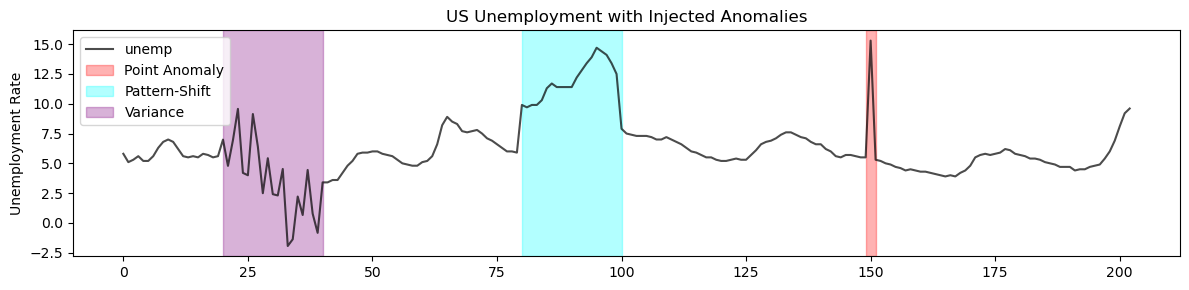

In [15]:
# Load the dataset (using .copy() to avoid SettingWithCopy warnings when mutating)
ts_arima = sm.datasets.macrodata.load_pandas().data.unemp.copy()

# 1. Point/Extremum Anomaly (Your original spike)
ts_arima.iloc[150] += 10.0

# 2. Pattern-Shift Anomaly (Level Shift)
ts_arima.iloc[80:100] += 4.0

# 3. Variance Anomaly (Noise Explosion)
np.random.seed(42)
ts_arima.iloc[20:40] += np.random.normal(0, 3.0, 20)

# Plot with highlight zones
ax = ts_arima.plot(title="US Unemployment with Injected Anomalies", figsize=(12, 3), color="black", alpha=0.7)
ax.axvspan(149, 151, color='red', alpha=0.3, label='Point Anomaly')
ax.axvspan(80, 100, color='cyan', alpha=0.3, label='Pattern-Shift')
ax.axvspan(20, 40, color='purple', alpha=0.3, label='Variance')
plt.ylabel("Unemployment Rate")
plt.legend()
plt.tight_layout()
plt.show()

ARIMA has 3 inputs: 
- **p**: Order of autoregressive part
- **d**: The number of differences required to make the time series stationary
- **q**: Order of moving average part

Those three parameters are not always intuitive to set. However, there have been (numerical) methods developed to determine each parameter. In the end, these are **guidelines** to make the model more precise. <br> **Auto-ARIMA** functions exist that try to automatically guess the three parameters. 

There are **special configurations** of ARIMA which are known to produce certain patterns, e.g. white noise (0, 0, 0), random walks (0, 1, 0), pure autoregression (p, 0, 0) or pure moving average (0, 0, q).

The amount of integration - how much the time series needs to be differenced - can be determined with e.g. the **Augmented Dickey-Fuller** (adfuller) or **Kwiatkowski–Phillips–Schmidt–Shin** (kpss) test. <br> The Augmented Dickey-Fuller test assumes a null hypothesis ($H_0$) that the time series has a unit root (is non-stationary). If the p-value is below our significance level (e.g., 0.05), we reject the null hypothesis and conclude the data is stationary.

We use the adfuller test here:

Undifferenced timeseries...
ADF Test Statistic: 0.143
Timeseries is stationary: False

Differencing the timeseries to make it stationary...
ADF Test Statistic: 0.0
Timeseries is stationary: True



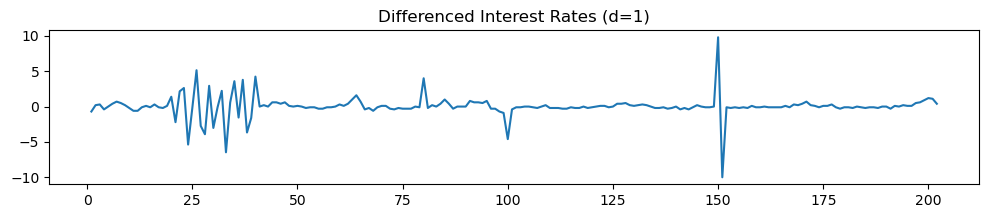

In [16]:
print("Undifferenced timeseries...")
print(f"ADF Test Statistic: {adfuller(ts_arima, autolag='AIC', regression='ct')[1].round(3)}")
print(f"Timeseries is stationary: {adfuller(ts_arima, autolag='AIC', regression='ct')[1] < 0.05}\n")

print("Differencing the timeseries to make it stationary...")
ts_diff = ts_arima.diff().dropna()

print(f"ADF Test Statistic: {adfuller(ts_diff, autolag='AIC', regression='ct')[1].round(5)}")
print(f"Timeseries is stationary: {adfuller(ts_diff, autolag='AIC', regression='ct')[1] < 0.05}\n")

_ = ts_diff.plot(title="Differenced Interest Rates (d=1)", figsize=(12, 2))

To determine the order of the AR and MA model, one can use **autocorrelation** and **partial autocorrelation** in some cases. The two plots have to follow a specific pattern - if both are too complex, the orders cannot be cleanly extracted. Both of the following methods work on the differenced input.

Autocorrelation describes the correlation of a time series to a shifted version of itself.
A peak (or cut-off) in the ACF suggests a correlation with past forecast errors. The lag at which the ACF cuts off can be used as the order ($q$) for the moving average model.

Partial autocorrelation removes the influence of all previous shifts. 
A peak in the PACF can suggest a higher correlation at this specific shift. The amount of shift can be used as the order ($p$) for the autoregressive model, which takes past values as input.

Auto-ARIMA uses a different method, called the **Hyndman-Khandakar algorithm**. It searches the parameter space (how to set $p$, $d$ and $q$) by evaluating all variable steps (increasing/decreasing $p$, $d$ or $q$) around the current configuration and continuing from the best choice.

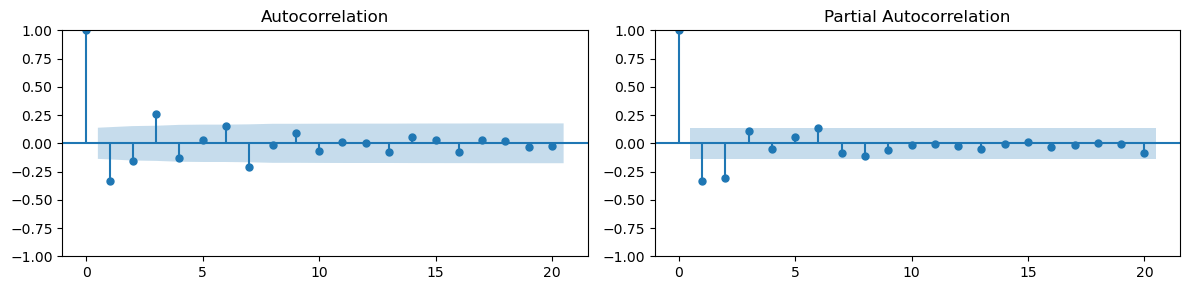

In [17]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 3))
plot_acf(ts_diff, ax=ax[0], lags=20)
plot_pacf(ts_diff, ax=ax[1], lags=20)

plt.tight_layout()
plt.show()

With the **significant spike** at 2 in the PACF plot and no such behaviour in the ACF plot, we can set p = 2 and q = 0. Together with the integration parameter d = 1, we have all the parameters we need.

Lets fit ARIMA and see the effect of the coefficients of the fitted model:

In [18]:
model = ARIMA(ts_arima, order=(2, 1, 0))
fitted_model = model.fit()

# Forecasting property of ARIMA
next_value = fitted_model.forecast(steps=1)
print(f"Next predicted value: {next_value.iloc[0]:.2f}")

future_values = fitted_model.forecast(steps=5)
print("\nNext 5 predicted values:")
print(future_values)

Next predicted value: 9.09

Next 5 predicted values:
203    9.093269
204    9.191173
205    9.302524
206    9.224650
207    9.224566
Name: predicted_mean, dtype: float64


When using ARIMA (or any forecasting model) for anomaly detection, it is crucial to distinguish between predicting the future and evaluating the past. <br> **Forecasting** involves projecting new, out-of-sample values into the unknown future. However, for anomaly detection, we rely on **in-sample predictions**. We ask the fitted ARIMA model to look back at the historical data it was just trained on and calculate what it expected each value to be, based on the autoregressive and moving average rules it learned. 

The difference between the actual observed value and the model's expectation is called the **residual**. If a data point produces a massive residual, it means that specific observation defied the established structural patterns of the time series, flagging it as an anomaly. We can filter for significant spikes in the residuals by determining a threshold, e.g. a multiple of the standard deviation like $3  \sigma$.

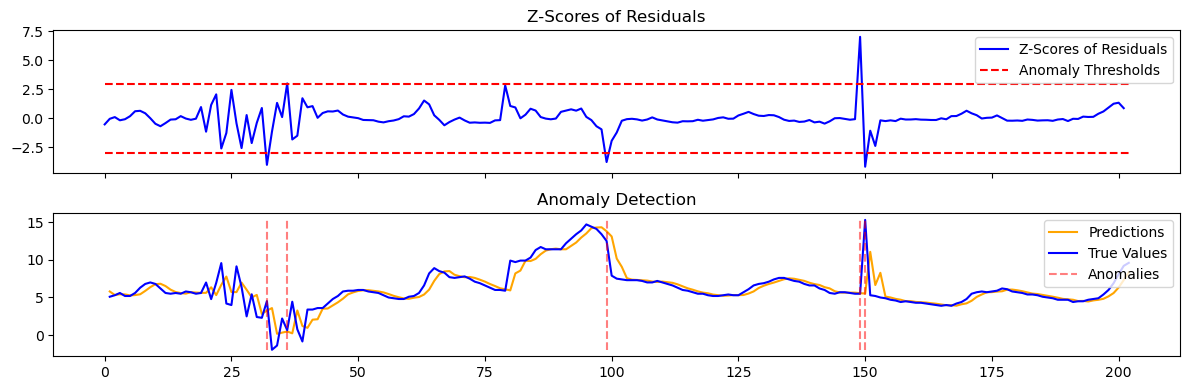

In [ ]:
anomaly_threshold = 3.0
predictions = fitted_model.predict()

warm_up = 1 # From which point to calculate the residual
residuals = ts_arima[warm_up:] - predictions[warm_up:]
z_scores = zscore(residuals)

# Plotting the residual and anomalies
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 4), sharex=True)

ax1.plot(z_scores, label="Z-Scores of Residuals", color="blue")
ax1.hlines([-anomaly_threshold, anomaly_threshold], color="red", linestyle="--", xmin=0, xmax=len(z_scores), label="Anomaly Thresholds")
ax1.set_title("Z-Scores of Residuals")
ax1.legend()

ax2.plot(predictions[warm_up:], label="Predictions", color="orange")
ax2.plot(ts_arima[warm_up:], label="True Values", color="blue")

anomalous_indices = np.where(np.abs(z_scores) > anomaly_threshold)[0]
ax2.vlines(anomalous_indices, ymin=ts_arima.min(), ymax=ts_arima.max(), color="red", alpha=0.5, linestyle="--", label="Anomalies")
ax2.set_title("Anomaly Detection")
ax2.legend()

plt.tight_layout()
plt.show()

## 3. DWT-MLEAD

DWT-MLEAD was the best **cost/benefit** ratio algorithm in the featured survey. However, it is more niche and complex than the previous two algorithms.

It is based on **wavelet transforms** of a time series to detect anomalies - it uses **haar wavelets** and stores their coefficients. If new values arrive that differ significantly from the current representation, an anomaly is flagged. As point anomalies might not trigger this difference for wavelets, a simple **heuristic** is included which flags anomalies if the values is significantly outside the current min-max range. 

DWT-MLEAD is designed as an **online** anomaly detection algorithm. However, most implementation in major time series libraries such as `aeon`, `dtaianomaly` or `TimeEval` as well as the survey implemented a batch wise offline version of the algorithm. The difference mainly lies in padding the time series to reach a length of a power of 2 and sometimes using a faster percentile threshold (i.e. flagging the 1% most anomalous points -> more false positives) instead of the $\chi^2$ threshold. However, we are implementing the original paper's version.

----

To understand how DWT-MLEAD operates online, we need to look at how it maintains a rolling mathematical memory of the time series. 

The algorithm projects the data into multiple **frequency levels** using Haar wavelets. Level 0 tracks the high-frequency raw data, while higher levels update less frequently, calculating the average (**approximation**) and difference (**detail**) of previous points to monitor long-term, slow-moving structural changes. To establish what "normal" looks like, the algorithm uses fixed-size windows to hold the most recent **wavelet coefficients** for each active level. The window sizes shrink for higher levels as they are already capturing a longer time frame.

It also utilizes helping variables, such as `prev_approx`, to temporarily store previous time steps, ensuring the continuous calculations remain efficient without needing to scan backward through the dataset.

Instead of recalculating the variance and mean of these windows from scratch at every step, the algorithm tracks the distribution in an online manner. It maintains a **distribution state** (dist_state) for each level that incorporates a **forgetting factor** so that older data naturally decays, allowing the model to adapt to gradual concept drift. This state is represented by a tuple holding four distinct items: The weight sum, rolling mean, inverse scatter matrix, and scatter matrix. 
- The **weight sum** tracks the effective number of recent observations, acting as the decaying denominator for our online calculations. 
- The **rolling mean** stores the exponentially weighted average of the wavelet coefficients within the current window. 
- To capture how the data spreads and varies over time, the **scatter matrix** tracks the moving sum of squared deviations from this mean. Finally, storing the **inverse scatter matrix** directly is what allows the algorithm to perform its rapid anomaly checks

When processing a new point, the algorithm enters a straightforward **update** and **predict** cycle. <br> 
First, the update phase seamlessly integrates the new data into the running distribution without having to recalculate heavy matrix math from scratch (a speedup achieved via the **Sherman-Morrison formula**). <br> 
Next, the predict phase measures how abnormally far the current window strays from this expected distribution (using **Mahalanobis distance**). If the deviation is too extreme and crosses a statistical limit (the $\chi^2$ significance threshold), that specific level casts a "vote." <br>
Finally, if enough levels vote for an anomaly, the global event counter trips, and a DWT anomaly is flagged.

Finally, because wavelets are built on averages, they can sometimes smooth over massive, sudden, single-point anomalies. To prevent this blind spot, the algorithm includes a fast safety net based on a **Min-Queue** heuristic. It utilizes highly efficient double-ended queues (`queue_min` and `queue_max`) to track the exact minimum and maximum of the current window in constant time. If a newly arriving value breaches this localized min-max range, the algorithm instantly bypasses the wavelet math and flags a heuristic anomaly.

In [ ]:
from scipy.stats import chi2
from collections import deque

class DWT_MLEAD():
    def __init__(self, max_levels=5, level_base=2.27, level_order=6, forgetting_factor=0.972, significance_level=0.01, global_anomaly_threshold=2.2):
        # 1: Parameter definition
        self.max_levels = max_levels
        self.level_base = level_base
        self.level_order = level_order
        self.forgetting_factor = forgetting_factor
        self.significance_level = significance_level
        self.global_anomaly_threshold = global_anomaly_threshold

        # 2: Variable initialization
        self.window_sizes = [max(1, int(np.floor(level_base ** (level_order - level)))) 
                             for level in range(max_levels)]
        self.global_event_counter = 0.0
        self.discount_factor = ((self.window_sizes[-1] - 1) / (self.window_sizes[-1] + 1))
        self.allow_anomaly = True

        # Holding weight sum, rolling mean, inverse scatter matrix, scatter matrix
        self.approx_dist_state = [(0.0, np.zeros(dim), np.identity(dim), np.identity(dim)) for dim in self.window_sizes]
        self.detail_dist_state = [(0.0, np.zeros(dim), np.identity(dim), np.identity(dim)) for dim in self.window_sizes]

        # 3: Helping variables
        self.approx_windows = [deque(maxlen=dim) for dim in self.window_sizes]
        self.detail_windows = [deque(maxlen=dim) for dim in self.window_sizes]

        self.prev_approx = [0.0] * self.max_levels
        
        self.queue_min = deque(maxlen=self.window_sizes[0])
        self.queue_max = deque(maxlen=self.window_sizes[0])

        self.transient_phase_length = max([self.window_sizes[l] * (2 ** l) for l in range(self.max_levels)])

    def dwt_mlead(self, time_step, current_value):
        """The parameter time_step expects 1-based indexing"""

        # 1: Check point anomaly heuristic
        c_min = self.queue_min[0][1] if self.queue_min else current_value
        c_max = -self.queue_max[0][1] if self.queue_max else current_value
        min_max_diff = c_max - c_min
        
        self._min_queue_update(self.queue_min, time_step, current_value)
        self._min_queue_update(self.queue_max, time_step, -current_value)
        
        heuristic_anomaly = False
        if (current_value < c_min - 0.2 * min_max_diff 
                 or current_value > c_max + 0.2 * min_max_diff):
            heuristic_anomaly = True

        # 2: Determine the maximum active frequency level
        max_active_level = 0
        for level in range(self.max_levels - 1, -1, -1):
            if time_step % (2 ** level) == 0:
                max_active_level = level
                break
        
        predictions_sum = 0
        current_approx = current_value

        # 3: View each wavelet level active at the time step
        for level in range(max_active_level + 1):
            # 3.1: Online Haare discrete wavelet transform
            if level == 0:
                approx_coeff = current_approx
                detail_coeff = current_approx
            else:
                prev_approx = self.prev_approx[level - 1]
                
                approx_coeff = (prev_approx + current_approx) / np.sqrt(2.0)
                detail_coeff = (prev_approx - current_approx) / np.sqrt(2.0)

            if level == max_active_level:
                self.prev_approx[level] = approx_coeff

            current_approx = approx_coeff

            # 3.2: Update sliding windows
            self.approx_windows[level].append(approx_coeff)
            self.detail_windows[level].append(detail_coeff)

            if len(self.approx_windows[level]) < self.window_sizes[level]:
                continue
            
            # 3.3: Update distributions
            detail_window = np.array(self.detail_windows[level])
            self.detail_dist_state[level] = self.update(self.detail_dist_state[level], detail_window, self.forgetting_factor)
            prediction = self.predict(self.detail_dist_state[level], detail_window, self.significance_level) 

            if level > 0:
                # Level 0 contains no approximation coefficients
                approx_window = np.array(self.approx_windows[level])
                self.approx_dist_state[level] = self.update(self.approx_dist_state[level], approx_window, self.forgetting_factor)
                prediction += self.predict(self.approx_dist_state[level], approx_window, self.significance_level) 

            # 3.4: Accumulate predictions
            predictions_sum += prediction

        # 4: Adjust global event counter
        self.global_event_counter = (
            self.discount_factor * self.global_event_counter + predictions_sum
        )

        if time_step <= self.transient_phase_length:
            return False

        # 5: Flag anomaly
        dwt_anomaly = (self.global_event_counter >= self.global_anomaly_threshold)
        is_anomaly = self.allow_anomaly and (dwt_anomaly or heuristic_anomaly)

        if is_anomaly:
            self.allow_anomaly = False

            if heuristic_anomaly and not dwt_anomaly:
                print(f"{time_step} Anomaly is heuristic")
                self.global_event_counter = self.global_anomaly_threshold

            else:
                print(f"{time_step} Anomaly is DWT")

        # 6: Allow new anomaly
        elif self.global_event_counter < (2.0/3.0) * self.global_anomaly_threshold:
            self.allow_anomaly = True

        return is_anomaly

    def update(self, dist_state, window, forgetting_factor):
        # 1: Unpack the current distribution state
        weight_sum, rolling_mean, inv_scatter_matrix, scatter_matrix = dist_state

        # 2: Decay the historical weight sum and add the new observation
        weight_sum = forgetting_factor * weight_sum + 1

        # 3: Calculate deviations and update the online rolling mean
        delta_window_mean = window - rolling_mean
        rolling_mean = rolling_mean + (1.0/weight_sum * delta_window_mean)
        delta_window_mean_updated = window - rolling_mean

        # 4: Update the scatter matrix (tracks variance/spread) - not necessary
        # scatter_matrix = forgetting_factor * scatter_matrix + np.outer(delta_window_mean, delta_window_mean_updated) #  matrix is optional
        
        # 5: Efficiently update the inverse scatter matrix using the Sherman-Morrison formula
        inv_scatter_matrix = (
            1.0/forgetting_factor * inv_scatter_matrix 
            - (1.0/forgetting_factor * np.outer(inv_scatter_matrix @ delta_window_mean, delta_window_mean_updated @ inv_scatter_matrix)
               / (forgetting_factor + np.dot(delta_window_mean_updated, inv_scatter_matrix @ delta_window_mean))
            )
        )

        return (weight_sum, rolling_mean, inv_scatter_matrix, scatter_matrix)

    def predict(self, dist_state, window, significance_level):
        # 1: Unpack the necessary distribution state variables
        weight_sum, rolling_mean, inv_scatter_matrix, scatter_matrix = dist_state

        # 2: Calculate the deviation of the current window from the rolling mean
        delta_window_mean = window - rolling_mean
        
        # 3: Compute the Mahalanobis distance (multi-dimensional Z-score)
        mahalanobis_distance = weight_sum * np.dot(delta_window_mean, inv_scatter_matrix @ delta_window_mean)

        # 4: Determine the chi-squared significance threshold based on window dimension
        dim = len(window)
        significance_threshold = chi2.ppf(1.0 - significance_level, df=dim)

        # 5: Return event flag
        return 1.0 if mahalanobis_distance > significance_threshold else 0.0

    def _min_queue_update(self, queue, time, value):
        # Pop current min if it slides out of the window
        if queue and queue[0][0] <= time - self.window_sizes[0]:
            queue.popleft()

        # Pop all value that are greater than the current value
        # as they cannot be the minimum of the window anymore
        while queue and queue[-1][1] >= value:
            queue.pop()

        # Append current value as potential minimum for next windows
        queue.append((time, value))

Let's try to detect our anomalies. We are simulating an online data stream by looping through our static data.

Within the paper they determined a set of parameters experimentally. Afterwards, they only vary the significance level for each dataset. Play with the parameters to see how longer window sizes or more levels etc can change the predictions.

201 Anomaly is heuristic
336 Anomaly is DWT
1216 Anomaly is DWT
1792 Anomaly is DWT
1808 Anomaly is DWT
1824 Anomaly is DWT
2064 Anomaly is DWT
2080 Anomaly is DWT


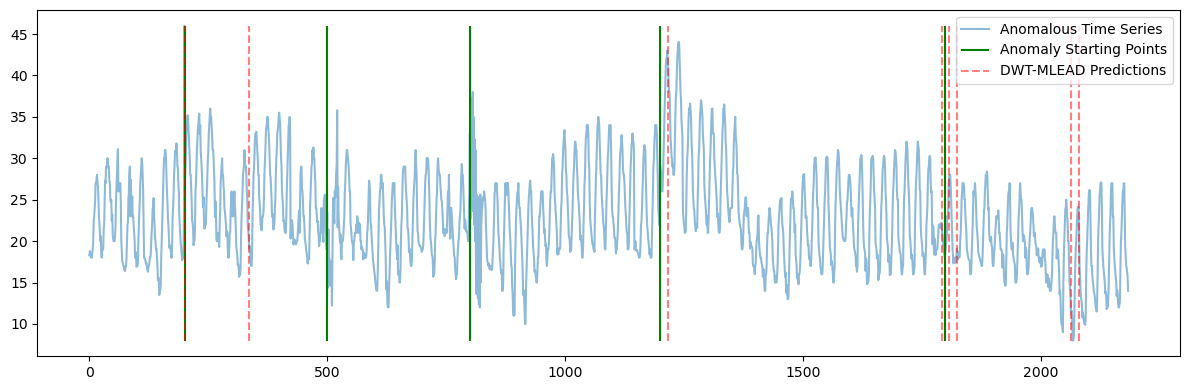

In [21]:
# Change the experimentally determined parameters to fit to our data
dwt_mlead = DWT_MLEAD(
    # max_levels=5, 
    # level_base=2.27, 
    # level_order=6, 
    # forgetting_factor=0.972, 
    # global_anomaly_threshold=2.2,
    significance_level=0.3
)

dtw_anomalies = []
for step, value in enumerate(ts_data_anomalous, start=1):
    dtw_anomaly = dwt_mlead.dwt_mlead(step, value)
    if dtw_anomaly:
        dtw_anomalies.append((step, value))

# Plot anomalies
plt.figure(figsize=(12, 4))
plt.plot(ts_data_anomalous, label="Anomalous Time Series", alpha=0.5)
plt.vlines(true_anomalies, ymin=min(ts_data_anomalous), ymax=max(ts_data_anomalous), color="green", label="Anomaly Starting Points")
plt.vlines([step for step, _ in dtw_anomalies], ymin=min(ts_data_anomalous), ymax=max(ts_data_anomalous), color="red", alpha=0.5, linestyle="--", label="DWT-MLEAD Predictions")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Isolation Forest

Isolation Forests belong to the family of ensemble **machine learning** algorithms (similar to Random Forests) but are explicitly designed for anomaly detection. 

Instead of trying to model what normal data looks like, this algorithm **isolates** anomalies by measuring how hard it is to separate a data point from the rest of the dataset. The algorithm works by randomly selecting a feature and randomly making split decisions. Because anomalies are sparse and statistically different, they get separated into their own leaf nodes very quickly. 

The number of random splits required to isolate a point is called its **path length**. Points with exceptionally short path lengths (isolated closer to the root of the tree) are flagged as anomalies.

----

There is a major catch when applying Isolation Forests to our data: standard Machine Learning models expect tabular data where every row is **independent and identically distributed**. They do not understand the sequential nature of time. If we just feed the algorithm raw temperatures, it evaluates each point in a vacuum, ignoring whether a value represents a sudden, unnatural spike or a natural daytime peak.

To make the Isolation Forest work on a time series, we must translate the sequence into a tabular format that gives the model memory and context. We achieve this through **Feature Engineering**:

- Rolling Statistics: By calculating the rolling standard deviation and rolling mean over a 24-hour window, we compress the recent history of the time series into a single row. The model can now compare the current temperature against the immediate past.

- Rate of Change: Taking the absolute difference between consecutive points helps the model spot unnatural, sudden jumps.
- Temporal Features: Injecting the hour of the day gives the model context about seasonality (e.g., recognizing that 30ºC is normal at 14:00 but highly anomalous at 03:00). 

By feeding these engineered features into the Isolation Forest, we allow a tabular algorithm to effectively hunt for anomalies in sequential data.

----

By using `sklearn.ensemble.IsolationForest`, we can train the forest on our engineered features to predict anomaly labels for each window.

The class takes a critical parameter called **contamination**, which defines the expected proportion of outliers in the dataset. In the original paper, anomalies are identified by calculating an anomaly score between 0 and 1 for each point, flagging those that score exceptionally high. However, relying on strict theoretical score thresholds often yields far too many false positives in noisy, real-world time series. Instead, we manually set it to 0.05 to force the algorithm to isolate only the top 5% most extreme data points.

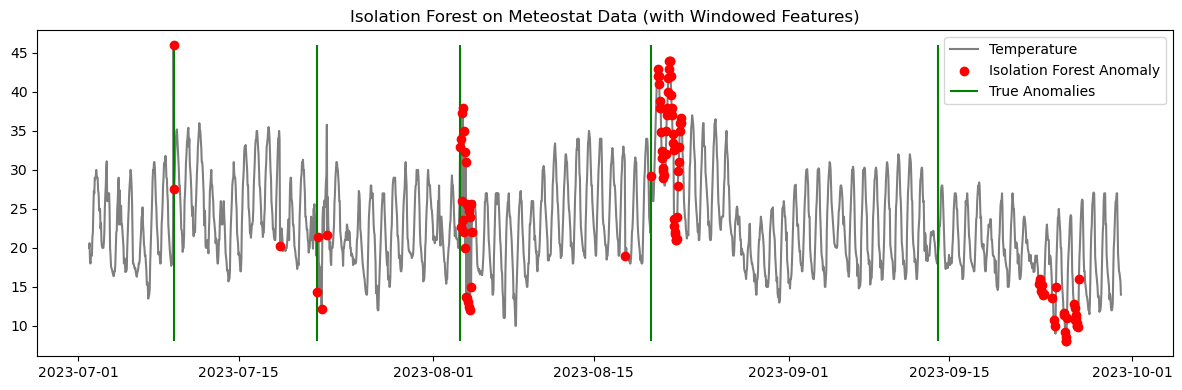

In [29]:
from sklearn.ensemble import IsolationForest

df_iso = pd.DataFrame({'temp': ts_data_anomalous}, index=ts_data.index)

# 1. Feature Engineering: Teach the model about time and structure
window = 24 
df_iso['rolling_std'] = df_iso['temp'].rolling(window=window).std()
df_iso['rolling_mean'] = df_iso['temp'].rolling(window=window).mean()
df_iso['rate_of_change'] = df_iso['temp'].diff().abs()
df_iso['hour_of_day'] = df_iso.index.hour
df_iso_clean = df_iso.dropna()

# 2. Train the Isolation Forest on the engineered features
features = ['temp', 'rolling_std', 'rolling_mean', 'rate_of_change', 'hour_of_day']
X = df_iso_clean[features]

clf = IsolationForest(contamination=0.05, random_state=42)
df_iso_clean['anomaly_label'] = clf.fit_predict(X)

# 3. Plot the results
plt.figure(figsize=(12, 4))
plt.plot(df_iso_clean.index, df_iso_clean['temp'], color='black', alpha=0.5, label='Temperature')

anomalies = df_iso_clean[df_iso_clean['anomaly_label'] == -1] # -1 indicates an anomaly in Isolation Forest
plt.scatter(anomalies.index, anomalies['temp'], color='red', label='Isolation Forest Anomaly', zorder=5)
true_anomaly_dates = ts_data.index[true_anomalies]
plt.vlines(true_anomaly_dates, ymin=min(ts_data_anomalous), ymax=max(ts_data_anomalous), color="green", label="True Anomalies")

plt.title("Isolation Forest on Meteostat Data (with Windowed Features)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Exercises
### 5.1. Matrix Profile
While our manual STOMP implementation speeds up the matrix profile calculation drastically, production environments typically use highly optimized, compiled libraries (often written in C or Cython). They can also utilize the parallizability of STOMP to speed up the calculation even more.

**Your Task:**
1. Import the `matrix_profile` module from the `tslearn` library.
2. Compute the matrix profile for our Bolzano temperature time series.
3. Compare the runtime of your `tslearn` implementation against our manual `matrix_profile_stomp` function using the `%%timeit` magic command.

In [23]:
from tslearn.matrix_profile import MatrixProfile

# 1. Initialize the tslearn MatrixProfile object
# TODO: Set the correct window_size (e.g., 20) and time series scale
ts_for_tslearn = ts.reshape(1, -1, 1) # tslearn expects 3D shape: (n_ts, sz, d)

# 2. Compute the profile
# TODO: Fit the model and extract the distances

# 3. Time the execution
# TODO: Compare runtimes using %%timeit

/home/moritz/miniconda3/envs/unibz-tsa-examples/lib/python3.14/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


So far, we have used the Matrix Profile to find the maximum distance (the discord/anomaly). However, the Matrix Profile is equally famous for finding **motifs** - the most repeated, similar patterns in a time series (the minimum distances).

**Your Task:**
1. Use the `matrix_profile` array we calculated earlier using STOMP.
2. Find the top 3 most similar pairs of windows (Top 3 Motifs) in the dataset.
3. Plot the time series and highlight these 3 pairs in different colors.

In [ ]:
# Create a copy of the profile so we don't destroy the original
mp_motifs = np.copy(matrix_profile)
motif_pairs = []

# TODO: Write a loop to find the top 3 motifs
# for _ in range(3):
    # 1. Find the index of the minimum value in mp_motifs
    # min_idx = ...
    
    # 2. Find its nearest neighbor using the matrix_profile_index
    # neighbor_idx = ...
    
    # 3. Append the pair to motif_pairs
    
    # 4. Apply an exclusion zone (e.g., -inf or +inf?) around min_idx and neighbor_idx 
    # to prevent trivial matches in the next iteration.

# TODO: Plot the time series and overlay the 3 motif pairs

_IncompleteInputError: incomplete input (4096427713.py, line 18)

### 5.2. ARIMA

Finding the optimal $p$, $d$, and $q$ parameters manually using ACF and PACF plots is subjective and time-consuming. The `pmdarima` library provides an `auto_arima` function that automates this search using the Hyndman-Khandakar algorithm.

**Your Task:**
1. Use `pmdarima` to automatically find the best ARIMA model for our `ts_arima` (US Unemployment) dataset.
2. Print the model summary.
3. Compare the AIC (Akaike Information Criterion) of the Auto-ARIMA model to the AIC of our manual $(2, 1, 0)$ model. Did the algorithm find a better fit?

In [ ]:
# Note: You may need to run `!pip install pmdarima` 
# import pmdarima as pm

# 1. Run Auto-ARIMA
# TODO: Use pm.auto_arima() on ts_arima. Consider setting trace=True to see the search process.
# best_model = pm.auto_arima(...)

# 2. Print summary
# TODO: Output the summary of the best model

# 3. Compare with manual model (Order 2, 1, 0)
# TODO: Fit the manual model again and compare the .aic() values

Standard ARIMA struggles with strongly seasonal data because it expects stationarity. Our Bolzano temperature data features a massive daily (24-hour) cycle. To forecast this, we must use SARIMA (Seasonal ARIMA), which introduces a second set of parameters $(P, D, Q, m)$ that operate on a seasonal lag.

**Your Task:**
Fit a SARIMA model to the first month of the Bolzano weather station data. 

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract exactly one month of hourly data (30 days * 24 hours = 720 hours)
ts_weather_week = ts_data_anomalous[:720]

# TODO: Define the standard order (p, d, q) and the seasonal order (P, D, Q, m)
# standard_order = (1, 0, 1) # Example starting point
# seasonal_order = (1, 1, 1, ?) # Replace ? with the correct seasonal period

# TODO: Fit the SARIMAX model
# seasonal_model = SARIMAX(ts_weather_week, order=standard_order, seasonal_order=seasonal_order)
# seasonal_fitted = seasonal_model.fit(disp=False)

# TODO: Plot the original week of data against the model's in-sample predictions

### 5.3. DWT-MLEAD

In our `DWT_MLEAD` class, we use the Sherman-Morrison formula to update the inverse scatter matrix. While mathematically elegant and highly efficient, recursively adding and multiplying small floats over thousands of time steps leads to **floating-point accumulation errors**. Over a long time series, the matrix can become unstable or non-invertible.

**Your Task:**
1. Create a subclass `Safe_DWT_MLEAD` that overrides the `update` method. Instead of using Sherman-Morrison, use `np.linalg.inv` to recalculate the inverse scatter matrix from scratch at every step.

2. Run both the original algorithm and your safe version on a long time series (e.g., 5000+ points). Do the final matrices differ? How much slower is the brute-force approach?
3. Think of a way to prevent this error without losing too much efficiency. Implement your hybrid approach.

In [ ]:
import time

class Safe_DWT_MLEAD(DWT_MLEAD):
    def update(self, dist_state, window, forgetting_factor):
        weight_sum, rolling_mean, inv_scatter_matrix, scatter_matrix = dist_state

        # TODO: Implement the standard updates for weight_sum and rolling_mean (copy from original)
        
        # TODO: Update the scatter matrix directly
        
        # TODO: Replace the Sherman-Morrison formula with direct inversion
        # Hint: Add a small regularization term (like np.eye(len(window)) * 1e-6) to the scatter_matrix 
        # before inverting to ensure it remains non-singular.
        # inv_scatter_matrix = np.linalg.inv(scatter_matrix + ...)        


        return (weight_sum, rolling_mean, inv_scatter_matrix, scatter_matrix)

# TODO: Generate or subset a long time series (n > 5000)
# long_ts = ...

# TODO: Time and execute the original DWT_MLEAD

# TODO: Time and execute the Safe_DWT_MLEAD

# TODO: Compare the final inv_scatter_matrix of both models for Level 0

### 5.4. Isolation Forest: The Art of Feature Engineering
Our Isolation Forest relied heavily on the features we engineered (rolling mean, rolling standard deviation, and hour of the day). Machine learning models are only as good as the features they are fed. 

**Your Task:**
1. **Window Size Impact:** Change the rolling window size from 24 hours to 3 hours, and then to 168 hours (1 week). How does this change the anomalies detected? 
2. **Feature Injection:** Add a new feature: `day_of_week`. (Hint: `df_iso.index.dayofweek`). 
3. **Evaluation:** Retrain the model and plot the results. Does the model now ignore temperature drops that happen regularly on weekends?

In [ ]:
# TODO: Recreate df_iso with the original datetime index
# df_iso = pd.DataFrame({'temp': ts_data_anomalous}, index=ts_data.index)

# TODO: Experiment with window = 3 and window = 168
# window = 3
# df_iso['rolling_std'] = ...
# df_iso['rolling_mean'] = ...

# TODO: Add 'day_of_week' as a new feature
# df_iso['day_of_week'] = ...

# TODO: Drop NaNs, define your features array, and retrain the IsolationForest

# TODO: Scatter plot the new anomalies over the original temperature data

### 5.5. Anomaly Detection Quality
In the real world, visual inspection isn't enough. We need to quantitatively evaluate our anomaly detection models. In our synthetic data, we saved the exact indices of the injected anomalies in the `true_anomalies` list.

**Your Task:**
Calculate the Precision, Recall, and $F_1$-score for our ARIMA residual threshold method. 

Use these prediction definitions for your logic:
*   **True Positive (TP):** The model flagged an anomaly within 12 hours (indices) of a `true_anomaly`.

*   **False Positive (FP):** The model flagged an anomaly, but there is no `true_anomaly` nearby.
*   **False Negative (FN):** There is a `true_anomaly`, but the model failed to flag it.

And these quality measures:
$$Precision = \frac{TP}{TP + FP}$$
$$Recall = \frac{TP}{TP + FN}$$
$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [ ]:
# The true anomaly starting indices:
# true_anomalies = 

# The anomalies predicted by ARIMA (from Section 2):
# predicted_anomalies = 

tolerance = 12 # hours
tp = 0
fp = 0
fn = 0

# TODO: Write logic to compare predicted_anomalies against true_anomalies using the tolerance

# TODO: Calculate Precision, Recall, and F1-Score

# print(f"Precision: {precision:.2f}")
# print(f"Recall: {recall:.2f}")
# print(f"F1-Score: {f1_score:.2f}")